In [17]:
from getArea import *
import pandas as pd
plt.rcParams["font.family"] = "Arial"

In [18]:
## import area data
file_name = 'ExportAreas20260122T093205.csv'
df_data = pd.read_csv(file_name)


In [19]:
## compute ratio 
df_ratio = []
for _group in df_data.Group.unique():
    _df = df_data[df_data['Group']==_group]
    _row_set = dict(_df.iterrows())
    for _row_key in _row_set:
        _row = _row_set[_row_key]
        _animal = _row['Animal']
        _area_vector = _row[['Area1','Area2','Area3','Area4']].to_numpy().astype(float)
        _ref_area_vecotr = _df[(_df['Animal']==_animal)&(_df[_df.columns[0]]=='DAY1')]
        _ref_area_vecotr = _ref_area_vecotr[['Area1','Area2','Area3','Area4']].to_numpy().astype(float)[0]
        _ratio_vector = _area_vector/_ref_area_vecotr
        _df_ratio = pd.DataFrame([[_row[_df.columns[0]],
                                   _row[_df.columns[1]],
                                   _ratio_vector[0],
                                   _ratio_vector[1],
                                   _ratio_vector[2],
                                   _ratio_vector[3],
                                   _group]],
                                 columns=_df.columns)
        
        df_ratio.append(_df_ratio)

df_ratio = pd.concat(df_ratio)
df_ratio['Day'] = df_ratio['# Time'].apply(lambda x:int(x[3:]))
df_ratio = df_ratio.sort_values(['Group','Day','Animal'])

df_data['Day'] = df_data['# Time'].apply(lambda x:int(x[3:]))
df_data = df_data.sort_values(['Group','Day','Animal'])

export_file_name = file_name.replace('Areas','Ratios')
df_ratio.to_csv(export_file_name)



In [20]:
## plot

# using real area
# df_plot = df_data.copy()

# using ratio
df_plot = df_ratio.copy()

# export dir
export_dir = 'exportFig/'
os.makedirs(export_dir,exist_ok=True)


In [21]:

df_series = []
n_area = 4
for _i_row,_row in df_plot.iterrows():
    _df_row = _row[['# Time','Animal','Group','Day']]
    for _i_area in np.arange(1,n_area+1):
        _col_name = 'Area'+str(_i_area)
        _df_row['Location'] = _i_area
        _df_row['Area'] = _row[_col_name]
        df_series.append(pd.DataFrame(_df_row).T)        
df_series = pd.concat(df_series)
df_series= df_series.reset_index(drop=True)

df_series_average = df_ratio.copy()
df_series_average['Area'] = df_series_average.apply(lambda x: np.mean([x['Area1'],x['Area2'],x['Area3'],x['Area4']]),axis= 1)


C:\Users\BenLa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\BenLa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\BenLa\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument

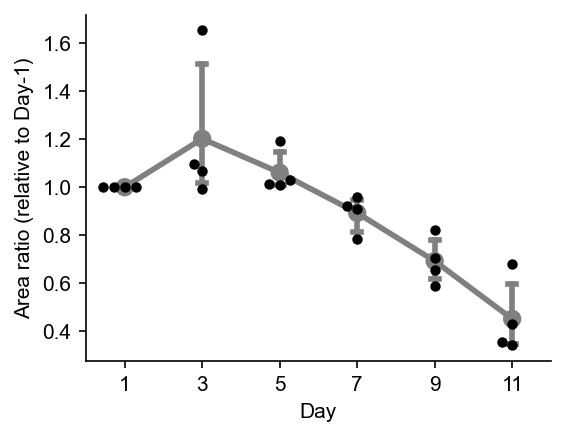

In [46]:
fig,ax = plt.subplots(figsize=[4,3],dpi = 150)
sns.pointplot(y = 'Area',x = 'Day',data = df_series,capsize=.1,color ='grey')
sns.swarmplot(y = 'Area',x = 'Day',data = df_series,color ='k')
sns.despine()

ax.set_ylabel('Area ratio (relative to Day-1)')
ax.set_xlabel('Day')
ax.legend(framealpha =0)
plt.savefig(export_dir+'AreaRatioTrend.png')